# Data Exploration

## Import Libraries

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import os
import kagglehub
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

## Import Data

In [18]:
!pip install --quiet pyarrow

In [20]:
path = kagglehub.dataset_download(
    "martj42/international-football-results-from-1872-to-2017"
)
print("Path to dataset files:", path)

Path to dataset files: /home/sagemaker-user/.cache/kagglehub/datasets/martj42/international-football-results-from-1872-to-2017/versions/98


In [21]:
results_path = os.path.join(path, "results.csv")
df = pd.read_csv(results_path, parse_dates=["date"])
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


## Data Exploration

In [12]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())
df.info()
display(df.describe(include="all"))

Shape: (48532, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
48527,2025-09-09,Bosnia and Herzegovina,Austria,1,2,FIFA World Cup qualification,Zenica,Bosnia and Herzegovina,False
48528,2025-09-09,Cyprus,Romania,2,2,FIFA World Cup qualification,Nicosia,Cyprus,False
48529,2025-09-09,Norway,Moldova,11,1,FIFA World Cup qualification,Oslo,Norway,False
48530,2025-09-09,Albania,Latvia,1,0,FIFA World Cup qualification,Tirana,Albania,False
48531,2025-09-09,Serbia,England,0,5,FIFA World Cup qualification,Belgrade,Serbia,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48532 entries, 0 to 48531
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        48532 non-null  datetime64[ns]
 1   home_team   48532 non-null  object        
 2   away_team   48532 non-null  object        
 3   home_score  48532 non-null  int64         
 4   away_score  48532 non-null  int64         
 5   tournament  48532 non-null  object        
 6   city        48532 non-null  object        
 7   country     48532 non-null  object        
 8   neutral     48532 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.0+ MB


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,48532,48532,48532,48532.000000,48532.000000,48532,48532,48532,48532
unique,NaN,325,318,NaN,NaN,188,2115,268,2
top,NaN,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,NaN,608,578,NaN,NaN,18116,736,1458,35751
mean,1993-10-17 04:11:45.579823488,NaN,NaN,1.758180,1.181550,NaN,NaN,NaN,NaN
min,1872-11-30 00:00:00,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1980-02-27 00:00:00,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,2000-03-15 00:00:00,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,2012-11-07 06:00:00,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN
max,2025-09-09 00:00:00,NaN,NaN,31.000000,21.000000,NaN,NaN,NaN,NaN


### Ununique and Null Values

In [11]:
print("Nulls per column:\n", df.isnull().sum())
print("\nUnique counts:\n", df.nunique())

Nulls per column:
 date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Unique counts:
 date          16348
home_team       325
away_team       318
home_score       26
away_score       22
tournament      188
city           2115
country         268
neutral           2
dtype: int64


### Data Distributions

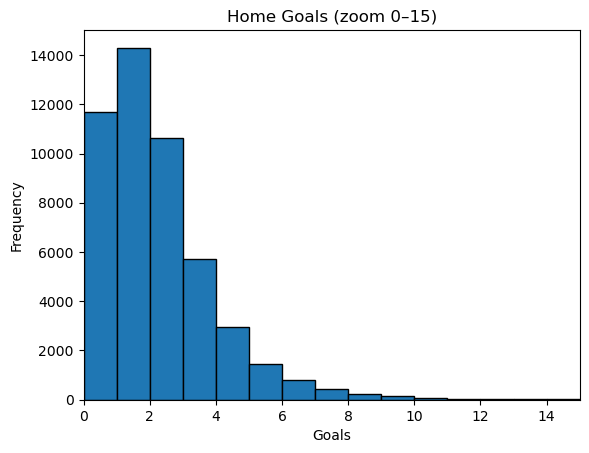

In [22]:
# Home goals (0–15)
ax = df["home_score"].plot.hist(bins=16, range=(0,16), edgecolor="black")
ax.set_title("Home Goals (zoom 0–15)")
ax.set_xlabel("Goals")
ax.set_xlim(0, 15)
plt.show()

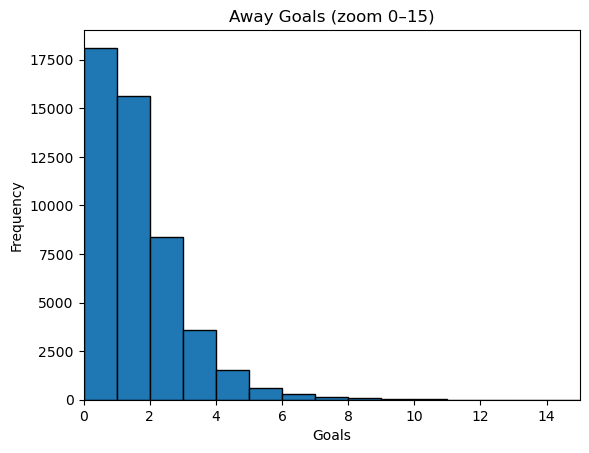

In [23]:
# Away goals (0–15)
ax = df["away_score"].plot.hist(bins=16, range=(0,16), edgecolor="black")
ax.set_title("Away Goals (zoom 0–15)")
ax.set_xlabel("Goals")
ax.set_xlim(0, 15)
plt.show()

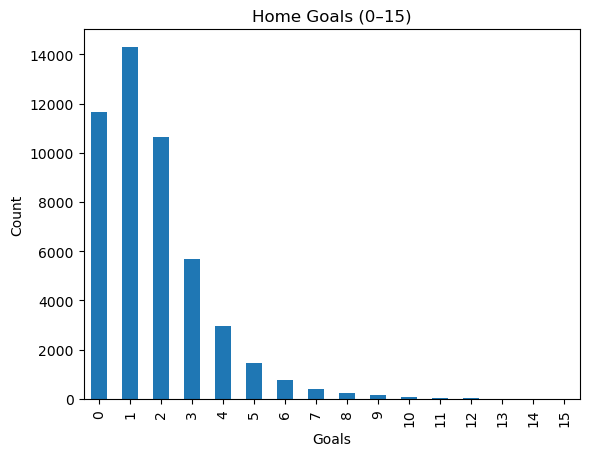

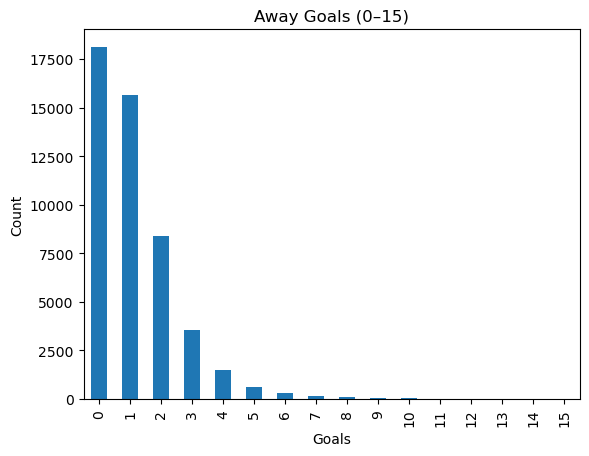

In [29]:
df["home_score"].value_counts().sort_index().loc[0:15].plot(kind="bar")
plt.title("Home Goals (0–15)")
plt.xlabel("Goals"); plt.ylabel("Count"); plt.show()

df["away_score"].value_counts().sort_index().loc[0:15].plot(kind="bar")
plt.title("Away Goals (0–15)")
plt.xlabel("Goals"); plt.ylabel("Count"); plt.show()

## Create Labels for Scoring at Home vs Scoring Away

In [24]:
df["result"] = np.where(df["home_score"] > df["away_score"], "Home Win",
                 np.where(df["home_score"] < df["away_score"], "Away Win", "Draw"))
df["goal_diff"] = df["home_score"] - df["away_score"]
df["year"] = df["date"].dt.year

result
Home Win    23797
Away Win    13700
Draw        11035
Name: count, dtype: int64


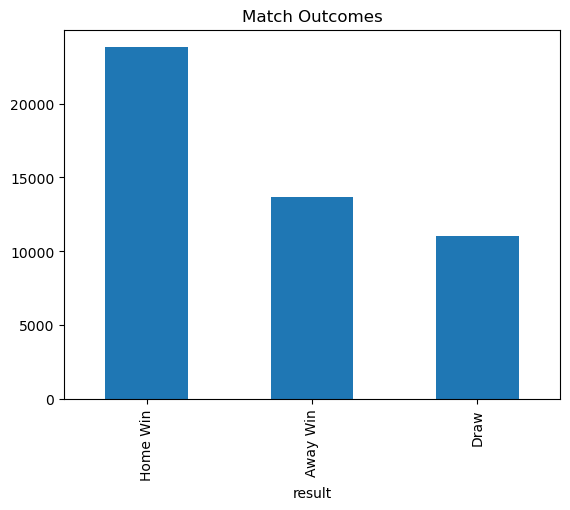

In [16]:
print(df["result"].value_counts())
df["result"].value_counts().plot(kind="bar", title="Match Outcomes"); plt.show()

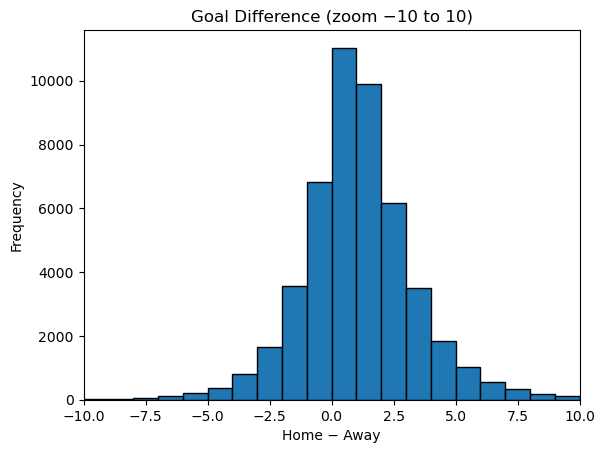

In [28]:
gd = df["home_score"] - df["away_score"]
ax = gd.plot.hist(bins=21, range=(-10,11), edgecolor="black")
ax.set_title("Goal Difference (zoom −10 to 10)")
ax.set_xlabel("Home − Away"); ax.set_xlim(-10, 10)
plt.show()

### Tren Graph Over Time

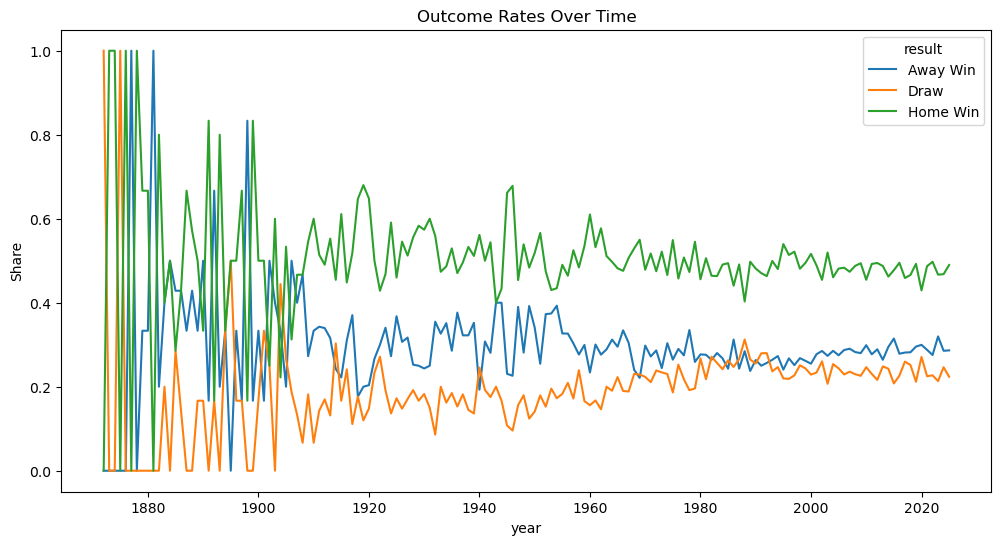

In [26]:
rate = (df.groupby("year")["result"].value_counts(normalize=True)
         .unstack().fillna(0.0))
rate.plot(kind="line", figsize=(12,6), title="Outcome Rates Over Time")
plt.ylabel("Share")
plt.show()

# Targat and Base Rate

result
Home Win    0.490
Away Win    0.282
Draw        0.227
Name: proportion, dtype: float64


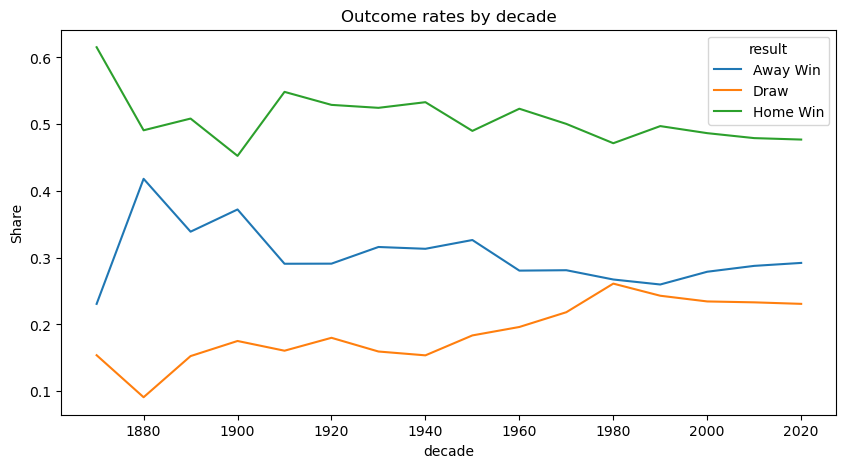

In [30]:
df["result"] = np.where(df.home_score>df.away_score,"Home Win",
                 np.where(df.home_score<df.away_score,"Away Win","Draw"))
df["decade"] = (df["date"].dt.year//10)*10

print(df["result"].value_counts(normalize=True).round(3))
df.groupby("decade")["result"].value_counts(normalize=True).unstack().plot(kind="line", title="Outcome rates by decade", figsize=(10,5))
plt.ylabel("Share"); plt.show()

### Class Imabalance Check

In [31]:
base = df["result"].mode()[0]
print("Most common class baseline:", base,
      " | accuracy:", (df["result"]==base).mean().round(3))

# Baseline: "home win unless neutral"
pred = np.where(df["neutral"], "Draw", "Home Win")
print("Heuristic baseline accuracy:", (pred==df["result"]).mean().round(3))

Most common class baseline: Home Win  | accuracy: 0.49
Heuristic baseline accuracy: 0.433


Both classes appear to have fairly good representation of each.

### Results View by venue Country

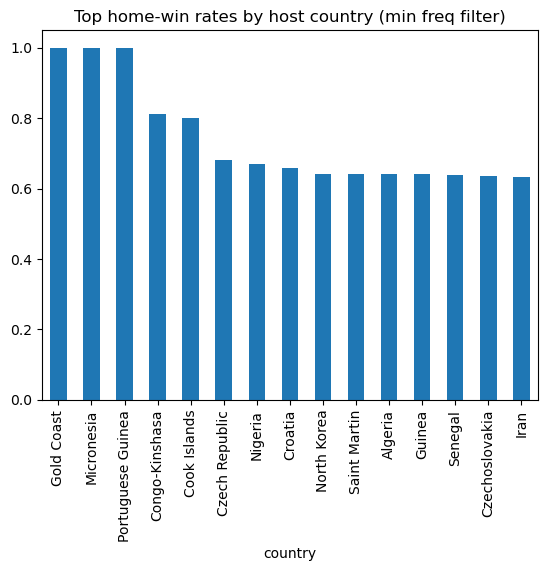

In [33]:
(df.assign(home_win=(df.home_score>df.away_score).astype(int))
   .groupby("country")["home_win"].mean()
   .sort_values(ascending=False).head(15)
   .plot(kind="bar", title="Top home-win rates by host country (min freq filter)"))
plt.show()

### Tournament/competition effect (friendlies vs qualifiers vs finals)

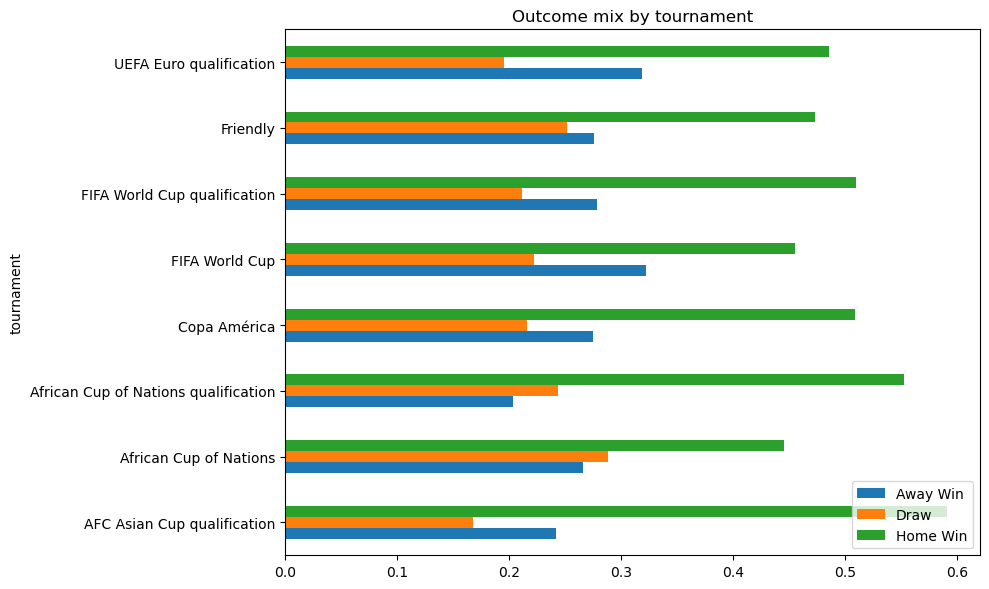

In [34]:
top_tourn = df["tournament"].value_counts().head(8).index
tmp = df[df["tournament"].isin(top_tourn)]
tmp.groupby("tournament")["result"].value_counts(normalize=True).unstack().plot(kind="barh", figsize=(10,6), title="Outcome mix by tournament")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### Leak Check

In [36]:
dupes = df.duplicated(subset=["date","home_team","away_team"], keep=False).sum()
print("Exact team/date duplicates:", dupes)

Exact team/date duplicates: 6


In [49]:
# Check for duplicates ( 6 rows with exact team and date)
# show all rows that collide on (date, home_team, away_team)
dups = (df[df.duplicated(subset=["date","home_team","away_team"], keep=False)]
          .sort_values(["date","home_team","away_team"]))
dups

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_diff,year,decade,home_win,home_winrate_5,away_win,away_winrate_5,home_form,away_form
9472,1973-09-04,Singapore,Malaysia,0,0,Southeast Asian Peninsular Games,Singapore,Singapore,0,Draw,0,1973,1970,0,0.2,0,0.2,0.2,0.2
9474,1973-09-04,Singapore,Malaysia,0,3,Southeast Asian Peninsular Games,Singapore,Singapore,0,Away Win,-3,1973,1970,0,0.2,1,0.4,0.2,0.4
9637,1974-02-17,Tahiti,New Caledonia,2,1,Friendly,Papeete,Tahiti,0,Home Win,1,1974,1970,1,0.6,0,0.2,0.6,0.2
9638,1974-02-17,Tahiti,New Caledonia,1,2,Friendly,Papeete,Tahiti,0,Away Win,-1,1974,1970,0,0.6,1,0.4,0.6,0.4
11169,1977-10-22,Guyana,Barbados,2,0,Friendly,Linden,Guyana,0,Home Win,2,1977,1970,1,0.6,0,0.0,0.6,0.0
11170,1977-10-22,Guyana,Barbados,0,0,Friendly,Georgetown,Guyana,0,Draw,0,1977,1970,0,0.4,0,0.0,0.4,0.0


There seem to have at least 3 duplicates here although the scores are different. It is very unlikely that these teams played a different game at the same day. For now, the rows will be left as is and comeback later at data cleanning step.

### Class Imbalance

In [37]:
base = df["result"].mode()[0]
print("Most common class baseline:", base,
      " | accuracy:", (df["result"]==base).mean().round(3))

# Slightly smarter baseline: "home win unless neutral"
pred = np.where(df["neutral"], "Draw", "Home Win")
print("Heuristic baseline accuracy:", (pred==df["result"]).mean().round(3))

Most common class baseline: Home Win  | accuracy: 0.49
Heuristic baseline accuracy: 0.433


### Simple Feature Association

In [47]:
df = df.sort_values("date").copy()

df["home_form"] = df["home_winrate_5"]
df["away_form"] = df["away_winrate_5"]


# Target confirmation
if "result" not in df.columns:
    df["result"] = np.where(df.home_score > df.away_score, "Home Win",
                     np.where(df.home_score < df.away_score, "Away Win", "Draw"))

# Feature matrix (adjust if you used different names)
X = pd.DataFrame({
    "goal_diff": df["home_score"] - df["away_score"],
    "home_form": df["home_winrate_5"],   # created earlier
    "away_form": df["away_winrate_5"],   # created earlier
    "neutral":   df["neutral"].astype(int)
}).dropna()

# Encode target
y = df.loc[X.index, "result"]
y_enc = LabelEncoder().fit_transform(y)  # Home Win/Draw/Away Win -> 0/1/2

# Mutual Information (higher = stronger association with target)
mi = mutual_info_classif(
    X, y_enc,
    discrete_features=[3],     # 'neutral' is discrete (0/1)
    random_state=0
)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("Mutual Information with target (higher is better):\n")
print(mi_scores.round(4))

# (Optional) Quick class-wise means for interpretability
print("\nClass-wise means (for intuition, not a test):\n")
print(df.loc[X.index].groupby("result")[["goal_diff","home_form","away_form","neutral"]]
        .mean().round(3))

Mutual Information with target (higher is better):

goal_diff    1.0437
away_form    0.1668
home_form    0.1644
neutral      0.0025
dtype: float64

Class-wise means (for intuition, not a test):

          goal_diff  home_form  away_form  neutral
result                                            
Away Win     -2.018      0.335      0.472    0.311
Draw          0.000      0.388      0.239    0.259
Home Win      2.338      0.626      0.191    0.238


### Number of Matchs per Year

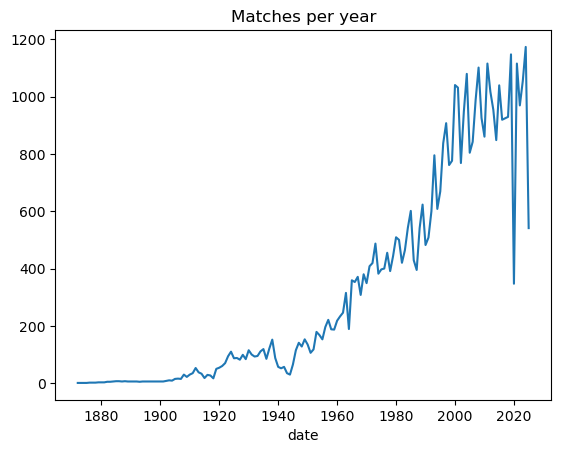

Years with very few matches: [1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1913, 1914, 1915, 1916, 1917, 1918, 1943, 1944]


In [44]:
matches_per_year = df.groupby(df["date"].dt.year).size()
matches_per_year.plot(kind="line", title="Matches per year"); plt.show()
print("Years with very few matches:", matches_per_year[matches_per_year<50].index.tolist())

The data seems to be pretty accurate. It shows that in 2020, the number of matches dropped substantially as this was affected by Covid-19.